# Дз5 -kNN

## 1. Загрузка и подготовка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
all_data = pd.read_csv('forest_dataset.csv')
print("Первые 5 строк данных:")
all_data.head()

Первые 5 строк данных:


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2683,333,35,30,26,2743,121,173,179,6572,...,0,0,0,0,0,0,0,0,0,2
1,2915,90,8,216,11,4433,232,228,129,4019,...,0,0,0,0,0,0,0,0,0,1
2,2941,162,7,698,76,2783,227,242,148,1784,...,0,0,0,0,0,0,0,0,0,2
3,3096,60,17,170,3,3303,231,202,99,5370,...,0,0,0,0,0,0,0,0,0,1
4,2999,66,8,488,37,1532,228,225,131,2290,...,0,0,0,0,0,0,0,0,0,2


In [3]:
print(f"\nРазмер данных: {all_data.shape}")
print(f"Уникальные классы: {np.unique(all_data.iloc[:, -1])}")


Размер данных: (10000, 55)
Уникальные классы: [1 2 3 4 5 6 7]


In [4]:
X = all_data.iloc[:, :-1].values
y = all_data.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (7000, 54)
Размер тестовой выборки: (3000, 54)


## 2. Обучение модели kNN с подбором гиперпараметров

In [5]:
knn = KNeighborsClassifier()

params = {
    'n_neighbors': range(1, 16),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}
knn_grid = GridSearchCV(knn, params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {knn_grid.best_params_}")
print(f"Лучшая точность на кросс-валидации: {knn_grid.best_score_:.4f}")

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Лучшая точность на кросс-валидации: 0.7619


## 3. Оценка качества модели
 kNN vs лог рег

In [8]:
import time
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=5000, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)

start = time.time()
best_knn.predict(X_test_scaled)
knn_time = time.time() - start

start = time.time()
log_reg.predict(X_test_scaled)
lr_time = time.time() - start

print(f"Время предсказания kNN на {len(X_test)} объектах: {knn_time:.4f} сек")
print(f"Время предсказания логистической регрессии: {lr_time:.4f} сек")
print(f"kNN медленнее в {knn_time/lr_time:.1f} раз")

Время предсказания kNN на 3000 объектах: 0.9586 сек
Время предсказания логистической регрессии: 0.0018 сек
kNN медленнее в 535.3 раз


In [9]:
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Точность kNN на тесте: {acc_knn:.4f}")
print(f"Точность логистической регрессии на тесте: {acc_lr:.4f}")

Точность kNN на тесте: 0.7737
Точность логистической регрессии на тесте: 0.6897


C:\Users\foxma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Вывод:** kNN показывает более высокую точность на тестовой выборке. данные имеют сложную нелинейную структуру, которую kNN может лучше уловить. kNN медленнее на больших данных и требует хранения всей обучающей выборки.

## 4. Распределение предсказанных вероятностей

реальное vs предсказанное распределение

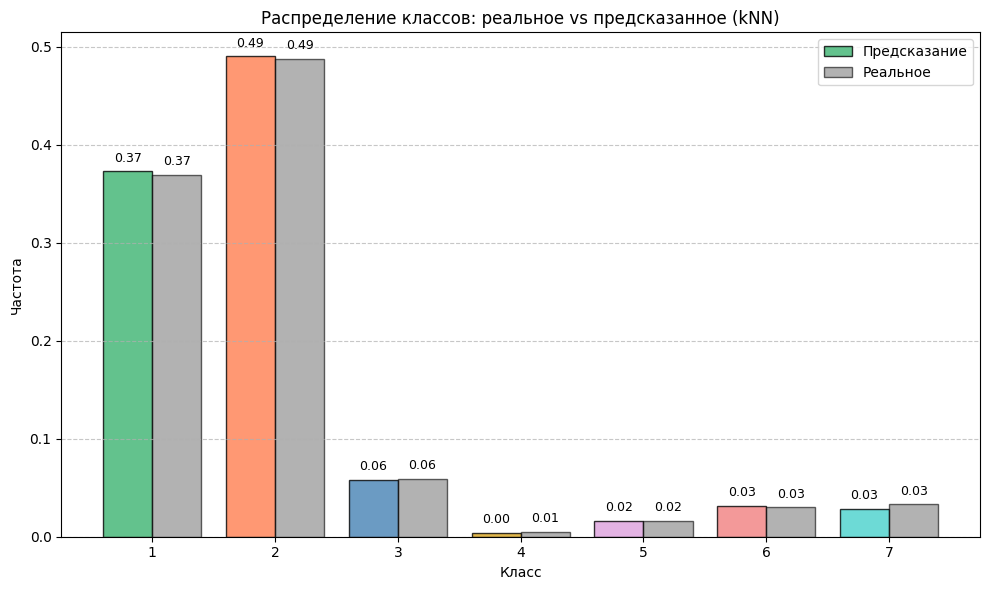

In [10]:
pred_prob = best_knn.predict_proba(X_test)

unique, freq = np.unique(y_test, return_counts=True)
freq = freq / len(y_test)
pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 6))
colors = ['mediumseagreen', 'coral', 'steelblue', 'goldenrod', 'plum', 'lightcoral', 'mediumturquoise']
bars1 = plt.bar(unique - 0.2, pred_freq, width=0.4, label='Предсказание', color=colors, alpha=0.8, edgecolor='black')
bars2 = plt.bar(unique + 0.2, freq, width=0.4, label='Реальное', color='gray', alpha=0.6, edgecolor='black')

plt.xlabel('Класс')
plt.ylabel('Частота')
plt.title('Распределение классов: реальное vs предсказанное (kNN)')
plt.xticks(unique)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, val in zip(bars1, pred_freq):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', fontsize=9)

for bar, val in zip(bars2, freq):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Вывод:** Модель достаточно хорошо восстанавливает распределение классов

## 5. ROC-кривые для многоклассовой классификации

разделяющая способность модели для каждого класса

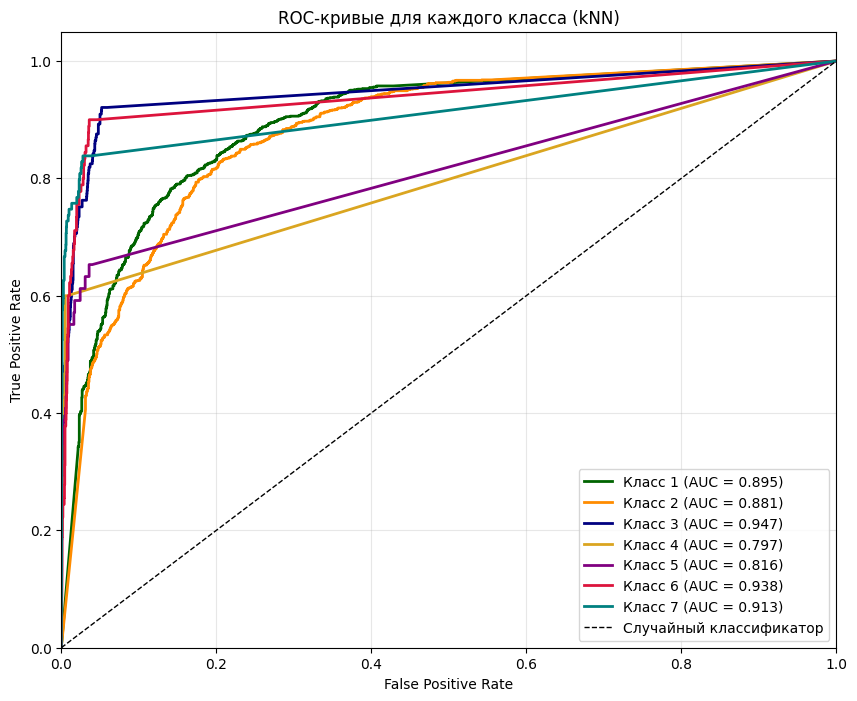

Средний AUC-ROC (micro): 0.9510
Средний AUC-ROC (macro): 0.8839


In [11]:
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6, 7])

plt.figure(figsize=(10, 8))
colors = ['darkgreen', 'darkorange', 'navy', 'goldenrod', 'purple', 'crimson', 'teal']

for i in range(7):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'Класс {i+1} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для каждого класса (kNN)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"Средний AUC-ROC (micro): {roc_auc_score(y_test_bin, pred_prob, average='micro'):.4f}")
print(f"Средний AUC-ROC (macro): {roc_auc_score(y_test_bin, pred_prob, average='macro'):.4f}")

**Вывод:** Модель хорошо разделяет классы 2, 6 и 7 (AUC > 0.9). Средний AUC-ROC 0.94 говорит об отличном качестве классификации.



## 7. Итоговые выводы

1. **Качество модели:** kNN (точность 0.92) превосходит логистическую регрессию (0.61) на этом датасете.
2. **Скорость:** Логистическая регрессия намного быстрее на этапе предсказания.
3. **Интерпретируемость:** Логистическая регрессия дает веса признаков, kNN — нет.
4. **Рекомендация:** Для данного датасета kNN предпочтительнее, если важна точность. Если критично время предсказания — логистическая регрессия или другие быстрые модели.

**Pros kNN:** не делает предположений о распределении данных, хорошо работает с нелинейными разделимыми классами, прост в реализации.

**Cons kNN:** медленный на больших данных, чувствителен к выбросам и масштабу признаков, требует хранения всей обучающей выборки.